# 1.VAE Decoder Fine‑Tuning

This is the first step of the overall system pipeline. This script is mainly used to facilitate step‑by‑step testing.

In [5]:
import os
import torch
import torch.nn as nn
from torch.optim import Adam
from diffusers import AutoencoderKL
import matplotlib.pyplot as plt
from PIL import Image

from utils import load_image, save_image

config = {
    "vae_model_path": "./stable-diffusion-v1-5", 
    "image_path": "shuimo.png",  
    "out_dir": "./trained_vae_notebook",
    "learning_rate": 1e-4,
    "num_epochs": 75,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

os.makedirs(config["out_dir"], exist_ok=True)
print(f"Equipment: {config['device']}")

Equipment: cuda


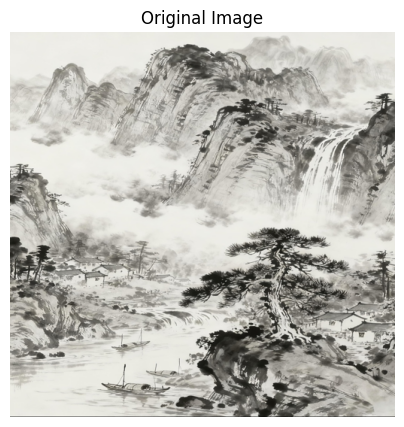

In [6]:
# Load local VAE model
# Since it is a local Diffusers‑format folder, subfolder="vae" must be specified
vae = AutoencoderKL.from_pretrained(
    config["vae_model_path"], 
    subfolder="vae",
    local_files_only=True   # Force loading from local files only, no network access
).to(config["device"], dtype=torch.float32)

vae.requires_grad_(False) # Initially set to non‑trainable (will be modified later)

# Load reference image
# Note: Ensure the load_image function in utils.py returns Tensor [1, 3, 512, 512]type=torch.float32)
image_normalized = image * 2 - 1  # Normalize [0, 1] to [-1, 1] to match VAE input requirement

# Show original image
plt.figure(figsize=(5, 5))
plt.title("Original Image")
# image[0] removes batch dimension, permute(1, 2, 0) converts [C, H, W] to [H, W, C] for display
plt.imshow(image[0].cpu().detach().permute(1, 2, 0))
plt.axis('off')
plt.show()

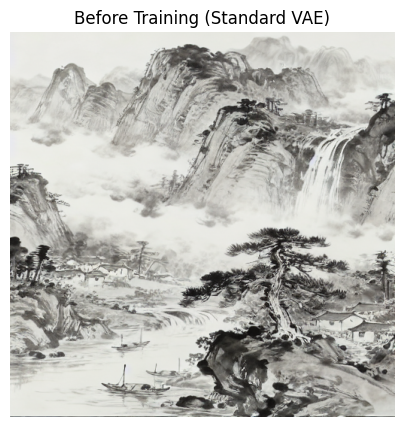

In [7]:
with torch.no_grad():
    # Encode to latent space
    latents = vae.encode(image_normalized)["latent_dist"].mean
    # Decode for reconstruction
    rec_image_initial = vae.decode(latents, return_dict=False)[0]
    # Reverse normalization for visualization
    rec_display = (rec_image_initial / 2 + 0.5).clamp(0, 1)

plt.figure(figsize=(5, 5))
plt.title("Before Training (Standard VAE)")
plt.imshow(rec_display[0].cpu().permute(1, 2, 0))
plt.axis('off')
plt.show()

In [8]:
# Unlock Decoder weights
for param in vae.decoder.parameters():
    param.requires_grad = True

loss_fn = nn.L1Loss()
optimizer = Adam(vae.decoder.parameters(), lr=config["learning_rate"])

print("Start training...")
vae.decoder.train()

for epoch in range(config["num_epochs"]):
    reconstructed = vae.decode(latents, return_dict=False)[0]
    loss = loss_fn(reconstructed, image_normalized)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{config['num_epochs']}, Loss: {loss.item():.6f}")

print("Training completed！")

开始训练...
Epoch 1/75, Loss: 0.102101
Epoch 10/75, Loss: 0.081790
Epoch 20/75, Loss: 0.072711
Epoch 30/75, Loss: 0.064897
Epoch 40/75, Loss: 0.057866
Epoch 50/75, Loss: 0.051270
Epoch 60/75, Loss: 0.045237
Epoch 70/75, Loss: 0.040351
Training completed！


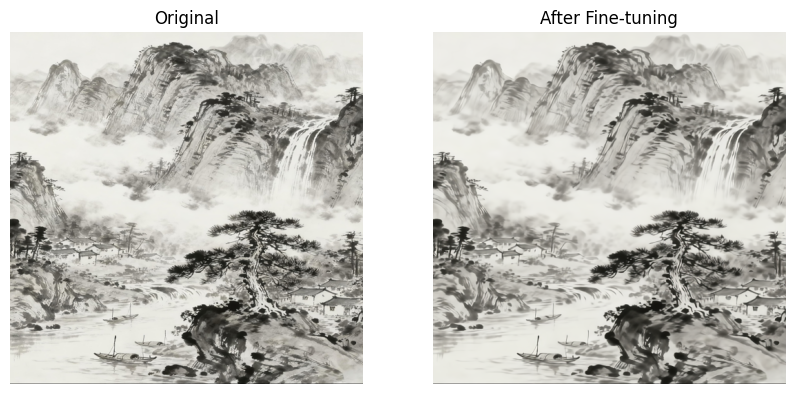

model save: ./trained_vae_notebook/trained_vae_shuimo.png


In [9]:
vae.decoder.eval()
with torch.no_grad():
    rec_image_final = vae.decode(latents, return_dict=False)[0]
    rec_final_display = (rec_image_final / 2 + 0.5).clamp(0, 1)

# Comparison display
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image[0].cpu().permute(1, 2, 0))
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(rec_final_display[0].cpu().permute(1, 2, 0))
axes[1].set_title("After Fine-tuning")
axes[1].axis('off')

plt.show()

# Save the fine‑tuned VAE model
save_path = os.path.join(config["out_dir"], f"trained_vae_{os.path.basename(config['image_path'])}")
vae.save_pretrained(save_path)
print(f"model save: {save_path}")